# Starter Code

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
 'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 90s 1us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


### Helper Functions

In [8]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te, 
                      epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    
    history = model.fit(x_tr, to_categorical(y_tr, 10),
                        validation_data=(x_v, to_categorical(y_v, 10)),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=cb, verbose=0)
    
    elapsed = time.time() - start
    
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    
    return history, test_acc, test_loss, elapsed


def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [10]:
# TEMP: assume standardized data (until Member 1 gives exact version)
x_train_std = x_train / 255.0
x_val_std   = x_val / 255.0
x_test_std  = x_test / 255.0

### Task 2A

In [12]:
def build_cnn_filters(f1, f2, f3, f4):
    model = models.Sequential([
        layers.Conv2D(f1, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(f2, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(f3, (3,3), activation='relu', padding='same'),
        layers.Conv2D(f4, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [13]:
configs = {
    "Small":  (8, 8, 16, 16),
    "Medium": (32, 32, 64, 64),
    "Large":  (64, 64, 128, 128)
}

histories = []
labels = []
results = []

for name, (f1, f2, f3, f4) in configs.items():
    print(f"\nTraining {name} model...")

    model = build_cnn_filters(f1, f2, f3, f4)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test
    )

    histories.append(history)
    labels.append(name)

    results.append([name, test_acc, elapsed])


Training Small model...


C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,266 (1.03 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,360,138 (9.00 MB)

 Trainable params: 2,360,138 (9.00 MB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7119 | Test Loss: 2.0459 | Time: 2864.1s


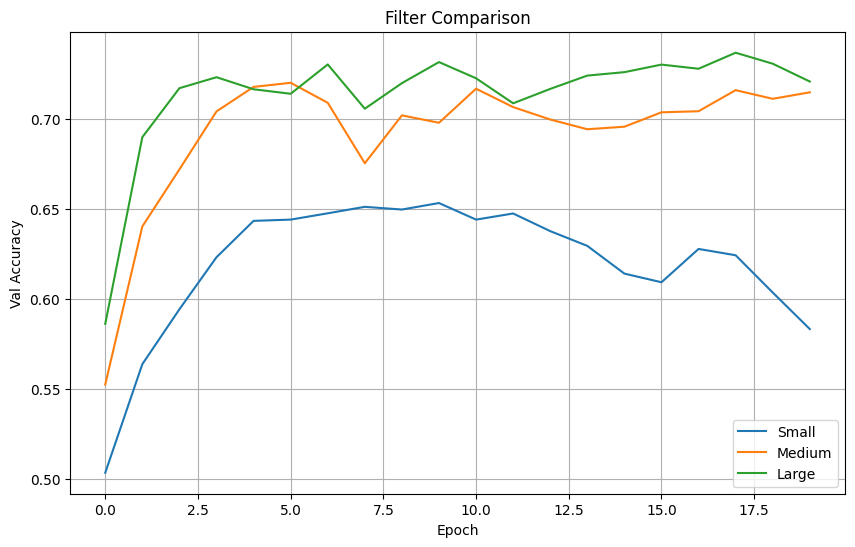

In [14]:
plot_curves(histories, labels, metric='val_accuracy', title='Filter Comparison', ylabel='Val Accuracy')

### Task 4A

In [15]:
optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad': keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001)
}

for name, opt in optimizers.items():
    print(f"\nTraining with {name}")

    model = build_cnn_filters(32,32,64,64)  # Medium model

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test
    )


Training with SGD
Test Acc: 0.3835 | Test Loss: 1.7783 | Time: 684.5s

Training with Momentum
Test Acc: 0.6022 | Test Loss: 1.1522 | Time: 735.7s

Training with AdaGrad
Test Acc: 0.4591 | Test Loss: 1.5112 | Time: 710.2s

Training with RMSProp
Test Acc: 0.6893 | Test Loss: 2.7650 | Time: 802.5s

Training with Adam
Test Acc: 0.7105 | Test Loss: 2.2362 | Time: 825.6s


### Task 4B

In [ ]:
lrs = [0.0001, 0.001, 0.01]

for lr in lrs:
    print(f"\nTraining with LR = {lr}")

    model = build_cnn_filters(32,32,64,64)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test
    )


Training with LR = 0.0001
